# An Exploration of the Potential Problems of Linear Regression

Author: Sofia Rodas

The text An Introduction to Statistical Learning with applications in Python lists six potential issues with linear regression. This notebook investigates three of those potential linear regression issues and provides further analysis of how they can manifest in data.

## 1. Non-linearity of the response-predictor

When constructing a linear regression it is assumed that the the predictor and the response have a "staight-line relationship". This linearity assumption is fundamental to getting accurate predictions from the model. From personal experience, plotting the data in a scatterplot is the first step to getting a rough understanding of the relationship between a predictor and the outcome and can give a visual of whether or not data is linearly correlated. Additionally, plotting residuals can reveal non-linearity. Any patterns in residual plots may indicate non-linearity of the data.


## 2. Correlations of Error Terms

The correlation of error terms occurs when we can understand or predict an error term of a model based on other error terms of the model. Correlation of error terms can lead to overconfidence in the model. This could manifest in a smaller range for the 95% confidence interval and a lower p-value than is truly achieved. Both of these would lead to a conclusion that the model fits the data than is the reality. The text mentions that doubling data would lead to a narrower range of confidence intervals. 

My question is how do you mitigate for the error term being correlated in a linear regression model?
Instead of using a linear regression model, a model that accounts for the correlation between measurements. Two options are a Generalized Estimating Equation (GEE) and a Multilevel Model (MLM), both resulting in more accurate error terms. GEE are best for analyzing data with repeated measurements for the same individuals. MLM are best to analyze within and between group interactions. MLM models require a relatively large sample size. 

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/fig1_problem.png'

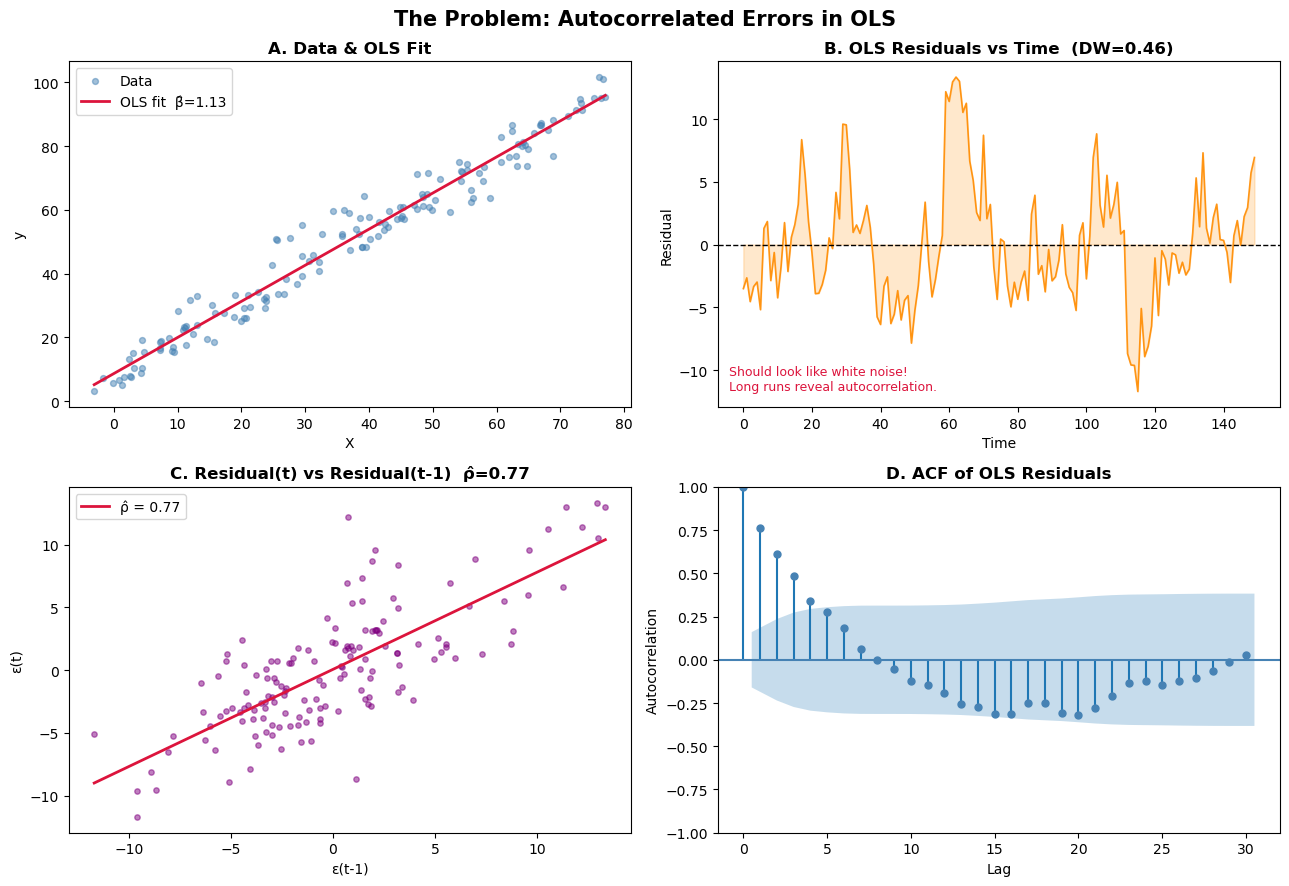

In [2]:
"""
Autocorrelation in Linear Regression Error Terms
=================================================
Shows: (1) the problem, (2) detection, (3) mitigation via GLS / Newey-West SEs
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.regression.linear_model import OLS, GLS
from statsmodels.tsa.stattools import acf
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.sandwich_covariance import cov_hac
import statsmodels.api as sm

np.random.seed(42)
n = 150

# ── Synthetic data with AR(1) errors ──────────────────────────────────────────
t = np.arange(n)
X = 0.5 * t + np.random.normal(0, 5, n)          # predictor correlated with time
X_const = sm.add_constant(X)

rho = 0.85                                         # strong autocorrelation
eps = np.zeros(n)
white_noise = np.random.normal(0, 3, n)
for i in range(1, n):
    eps[i] = rho * eps[i-1] + white_noise[i]      # AR(1) errors

beta_true = [5, 1.2]
y = beta_true[0] + beta_true[1] * X + eps

# ── OLS fit ───────────────────────────────────────────────────────────────────
ols_model = OLS(y, X_const).fit()
ols_resid  = ols_model.resid
dw_stat    = durbin_watson(ols_resid)

# ── GLS fit (Cochrane-Orcutt style: estimate rho, transform) ──────────────────
rho_est = np.corrcoef(ols_resid[:-1], ols_resid[1:])[0, 1]

y_gls  = y[1:]  - rho_est * y[:-1]
X_gls  = X[1:]  - rho_est * X[:-1]
X_gls_const = sm.add_constant(X_gls)
gls_model   = OLS(y_gls, X_gls_const).fit()
gls_resid   = gls_model.resid

# ── Newey-West (HAC) standard errors on OLS ───────────────────────────────────
hac_cov  = cov_hac(ols_model, nlags=10)
ols_nw   = ols_model.get_robustcov_results(cov_type='HAC', maxlags=10)


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — The Problem
# ══════════════════════════════════════════════════════════════════════════════
fig1, axes = plt.subplots(2, 2, figsize=(13, 9))
fig1.suptitle("The Problem: Autocorrelated Errors in OLS", fontsize=15, fontweight='bold')

# Panel A — raw data
ax = axes[0, 0]
ax.scatter(X, y, alpha=0.5, s=18, color='steelblue', label='Data')
x_line = np.linspace(X.min(), X.max(), 200)
ax.plot(x_line, ols_model.params[0] + ols_model.params[1]*x_line,
        color='crimson', lw=2, label=f'OLS fit  β̂={ols_model.params[1]:.2f}')
ax.set_title("A. Data & OLS Fit", fontweight='bold')
ax.set_xlabel("X"); ax.set_ylabel("y")
ax.legend()

# Panel B — residuals over time (shows the pattern)
ax = axes[0, 1]
ax.plot(t, ols_resid, color='darkorange', lw=1.2, alpha=0.9)
ax.axhline(0, color='black', lw=1, ls='--')
ax.fill_between(t, ols_resid, alpha=0.2, color='darkorange')
ax.set_title(f"B. OLS Residuals vs Time  (DW={dw_stat:.2f})", fontweight='bold')
ax.set_xlabel("Time"); ax.set_ylabel("Residual")
ax.annotate("Should look like white noise!\nLong runs reveal autocorrelation.",
            xy=(0.02, 0.05), xycoords='axes fraction', fontsize=9, color='crimson')

# Panel C — residuals lagged scatter
ax = axes[1, 0]
ax.scatter(ols_resid[:-1], ols_resid[1:], alpha=0.5, s=15, color='purple')
m, b = np.polyfit(ols_resid[:-1], ols_resid[1:], 1)
xr = np.linspace(ols_resid.min(), ols_resid.max(), 100)
ax.plot(xr, m*xr + b, color='crimson', lw=2, label=f'ρ̂ = {rho_est:.2f}')
ax.set_title(f"C. Residual(t) vs Residual(t-1)  ρ̂={rho_est:.2f}", fontweight='bold')
ax.set_xlabel("ε(t-1)"); ax.set_ylabel("ε(t)")
ax.legend()

# Panel D — ACF of residuals
ax = axes[1, 1]
plot_acf(ols_resid, lags=30, ax=ax, color='steelblue', alpha=0.05)
ax.set_title("D. ACF of OLS Residuals", fontweight='bold')
ax.set_xlabel("Lag"); ax.set_ylabel("Autocorrelation")

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fig1_problem.png", dpi=150, bbox_inches='tight')
plt.close()
print("Saved fig1_problem.png")


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Why It Matters: OLS SEs are too small
# ══════════════════════════════════════════════════════════════════════════════
fig2, axes = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle("Why It Matters: OLS Underestimates Standard Errors → False Precision",
              fontsize=14, fontweight='bold')

methods   = ['OLS\n(naive)', 'Newey-West\n(HAC)', 'GLS\n(Cochrane-Orcutt)']
betas     = [ols_model.params[1], ols_nw.params[1], gls_model.params[1]]
se_vals   = [ols_model.bse[1],    ols_nw.bse[1],    gls_model.bse[1]]
colors    = ['crimson', 'steelblue', 'seagreen']

ax = axes[0]
bars = ax.bar(methods, se_vals, color=colors, width=0.5, alpha=0.85, edgecolor='black')
ax.axhline(se_vals[1], color='steelblue', ls='--', lw=1.5, alpha=0.6, label='HAC SE (reference)')
ax.set_ylabel("Std. Error of β̂₁")
ax.set_title("A. Standard Errors of Slope Estimate", fontweight='bold')
for bar, val in zip(bars, se_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.annotate("OLS SE is too small → t-stats inflated\n→ spurious significance",
            xy=(0.03, 0.88), xycoords='axes fraction', fontsize=9, color='crimson',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

ax = axes[1]
ci_half = [1.96 * se for se in se_vals]
ax.errorbar(range(3), betas, yerr=ci_half, fmt='o', color='black',
            capsize=8, capthick=2, elinewidth=2)
for i, (b, c) in enumerate(zip(betas, colors)):
    ax.plot(i, b, 'o', color=c, markersize=12, zorder=5)
ax.axhline(beta_true[1], color='gold', ls='--', lw=2, label=f'True β={beta_true[1]}')
ax.set_xticks(range(3)); ax.set_xticklabels(methods)
ax.set_ylabel("β̂₁ ± 1.96·SE")
ax.set_title("B. 95% Confidence Intervals for Slope", fontweight='bold')
ax.legend()

plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/fig2_why_it_matters.png", dpi=150, bbox_inches='tight')
plt.close()
print("Saved fig2_why_it_matters.png")


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Mitigation
# ══════════════════════════════════════════════════════════════════════════════
fig3, axes = plt.subplots(2, 2, figsize=(13, 9))
fig3.suptitle("Mitigation: GLS (Cochrane-Orcutt) & Newey-West HAC Standard Errors",
              fontsize=14, fontweight='bold')

# Panel A — GLS transformed data
ax = axes[0, 0]
ax.scatter(X_gls, y_gls, alpha=0.5, s=18, color='seagreen', label='GLS-transformed data')
xg_line = np.linspace(X_gls.min(), X_gls.max(), 200)
ax.plot(xg_line, gls_model.params[0] + gls_model.params[1]*xg_line,
        color='darkgreen', lw=2, label=f'GLS fit  β̂={gls_model.params[1]:.2f}')
ax.set_title(f"A. GLS Transformed Data  (ρ̂={rho_est:.2f} removed)", fontweight='bold')
ax.set_xlabel("X* = X - ρ̂·X(t-1)"); ax.set_ylabel("y* = y - ρ̂·y(t-1)")
ax.legend()

# Panel B — GLS residuals over time
gls_dw = durbin_watson(gls_resid)
ax = axes[0, 1]
ax.plot(np.arange(len(gls_resid)), gls_resid, color='seagreen', lw=1.2, alpha=0.9)
ax.axhline(0, color='black', lw=1, ls='--')
ax.fill_between(np.arange(len(gls_resid)), gls_resid, alpha=0.2, color='seagreen')
ax.set_title(f"B. GLS Residuals vs Time  (DW={gls_dw:.2f})", fontweight='bold')
ax.set_xlabel("Time"); ax.set_ylabel("Residual")
ax.annotate("DW≈2 means no autocorrelation ✓",
            xy=(0.02, 0.05), xycoords='axes fraction', fontsize=9, color='seagreen')

# Panel C — ACF comparison
ax = axes[1, 0]
acf_ols = acf(ols_resid, nlags=20, fft=True)
acf_gls = acf(gls_resid, nlags=20, fft=True)
lags = np.arange(21)
ax.bar(lags - 0.2, acf_ols, width=0.35, color='crimson',   alpha=0.75, label='OLS residuals')
ax.bar(lags + 0.2, acf_gls, width=0.35, color='seagreen',  alpha=0.75, label='GLS residuals')
ci = 1.96 / np.sqrt(n)
ax.axhline( ci, color='black', ls='--', lw=1, alpha=0.5)
ax.axhline(-ci, color='black', ls='--', lw=1, alpha=0.5)
ax.set_title("C. ACF: OLS vs GLS Residuals", fontweight='bold')
ax.set_xlabel("Lag"); ax.set_ylabel("Autocorrelation")
ax.legend()

# Panel D — Summary table as text
ax = axes[1, 1]
ax.axis('off')
summary = [
    ["Method", "β̂₁", "SE(β̂₁)", "DW stat", "Approach"],
    ["OLS (naive)",       f"{ols_model.params[1]:.3f}", f"{ols_model.bse[1]:.3f}",
     f"{dw_stat:.2f}", "Ignore problem"],
    ["OLS + HAC SEs",     f"{ols_nw.params[1]:.3f}",   f"{ols_nw.bse[1]:.3f}",
     f"{dw_stat:.2f}", "Robust SEs only"],
    ["GLS (C-O)",         f"{gls_model.params[1]:.3f}", f"{gls_model.bse[1]:.3f}",
     f"{gls_dw:.2f}",  "Transform data"],
    ["True β₁",          f"{beta_true[1]:.3f}",        "—", "—", "—"],
]
table = ax.table(cellText=summary[1:], colLabels=summary[0],
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.1, 2.0)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row == 3:  # GLS row
        cell.set_facecolor('#d5f5e3')
    elif row == 2:
        cell.set_facecolor('#d6eaf8')
ax.set_title("D. Results Summary", fontweight='bold', pad=20)

plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/fig3_mitigation.png", dpi=150, bbox_inches='tight')
plt.close()
print("Saved fig3_mitigation.png")

print("\n=== KEY RESULTS ===")
print(f"True β₁:              {beta_true[1]:.3f}")
print(f"OLS β̂₁:              {ols_model.params[1]:.3f}  SE={ols_model.bse[1]:.3f}  DW={dw_stat:.2f}")
print(f"OLS+HAC β̂₁:          {ols_nw.params[1]:.3f}  SE={ols_nw.bse[1]:.3f}")
print(f"GLS (C-O) β̂₁:        {gls_model.params[1]:.3f}  SE={gls_model.bse[1]:.3f}  DW={gls_dw:.2f}")
print(f"\nEstimated ρ: {rho_est:.3f}  (true ρ={rho})")

Claude output: GLS / Cochrane-Orcutt: Estimates ρ̂, quasi-differences the data (y* = y − ρ̂·y_{t-1}), and runs OLS on the transformed data. DW goes from 0.46 → 2.03, and β̂ is closer to the true value (1.186 vs 1.200).

Newey-West HAC standard errors: Keeps the OLS estimates but corrects the SEs, giving valid inference without transforming the data — useful when you care more about correct inference than efficiency.